In [ ]:

!pip install imbalanced-learn xgboost -q


In [2]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import joblib

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Create ALL required directories (FIXES BUG #3)
os.makedirs('./data', exist_ok=True)
os.makedirs('./assets', exist_ok=True)
os.makedirs('./models', exist_ok=True)

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [3]:
# Column names per UCI specification
columns = [
    'Status_of_existing_checking_account', 'Duration_in_month', 'Credit_history',
    'Purpose', 'Credit_amount', 'Savings_account_bonds', 'Present_employment_since',
    'Installment_rate_in_percentage_of_disposable_income', 'Personal_status_and_sex',
    'Other_debtors_guarantors', 'Present_residence_since', 'Property', 'Age_in_years',
    'Other_installment_plans', 'Housing', 'Number_of_existing_credits_at_this_bank',
    'Job', 'Number_of_people_being_liable_to_provide_maintenance_for', 'Telephone',
    'Foreign_worker', 'Class'
]

# Try to load from local file first; if not found, download from UCI
local_path = './data/german_credit.csv'

if os.path.exists(local_path):
    df = pd.read_csv(local_path)
    print(f"✓ Loaded dataset from {local_path}")
else:
    # Fallback: download from UCI
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'
    df = pd.read_csv(url, sep=' ', header=None, names=columns)
    df.to_csv(local_path, index=False)
    print(f"✓ Downloaded dataset from UCI and saved to {local_path}")

# Remap target: Class (1=Good, 2=Bad) → (1=Good, 0=Bad)
df['Class'] = df['Class'].map({1: 1, 2: 0})

# Quick preview
print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{df['Class'].value_counts()}")

✓ Downloaded dataset from UCI and saved to ./data/german_credit.csv
Dataset shape: (1000, 21)
Target distribution:
Class
1    700
0    300
Name: count, dtype: int64


In [4]:
# Display basic dataset information
print("=== DATASET INFO ===")
print(df.info())

print("\n=== DESCRIPTIVE STATISTICS ===")
print(df.describe())

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                                                    Non-Null Count  Dtype 
---  ------                                                    --------------  ----- 
 0   Status_of_existing_checking_account                       1000 non-null   object
 1   Duration_in_month                                         1000 non-null   int64 
 2   Credit_history                                            1000 non-null   object
 3   Purpose                                                   1000 non-null   object
 4   Credit_amount                                             1000 non-null   int64 
 5   Savings_account_bonds                                     1000 non-null   object
 6   Present_employment_since                                  1000 non-null   object
 7   Installment_rate_in_percentage_of_disposable_income       1000 non-null   int64 
 8   Personal

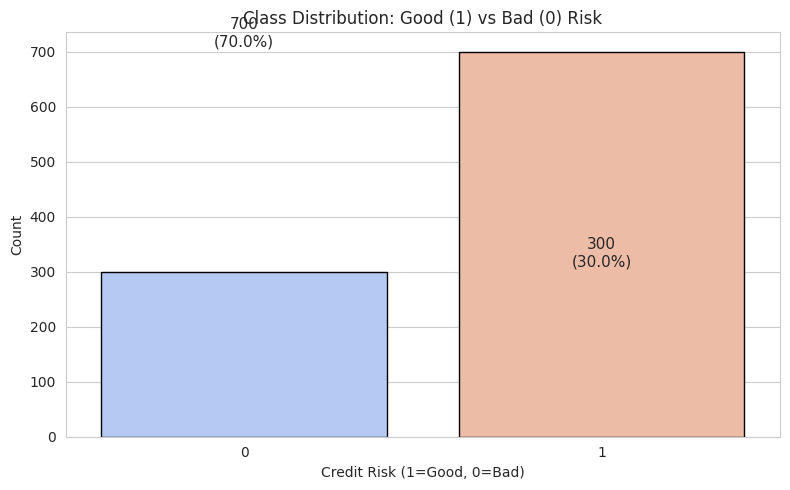

✓ Saved class balance plot to ./assets/class_balance.png


In [5]:
# Count and percentage of each class
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

# Create and save the plot
plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='coolwarm', edgecolor='black')
plt.title('Class Distribution: Good (1) vs Bad (0) Risk')
plt.xlabel('Credit Risk (1=Good, 0=Bad)')
plt.ylabel('Count')

# Add labels on bars
for i, (count, pct) in enumerate(zip(class_counts.values, class_pct.values)):
    plt.text(i, count + 10, f'{count}\n({pct:.1f}%)', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('./assets/class_balance.png', dpi=300)
plt.show()
print("✓ Saved class balance plot to ./assets/class_balance.png")

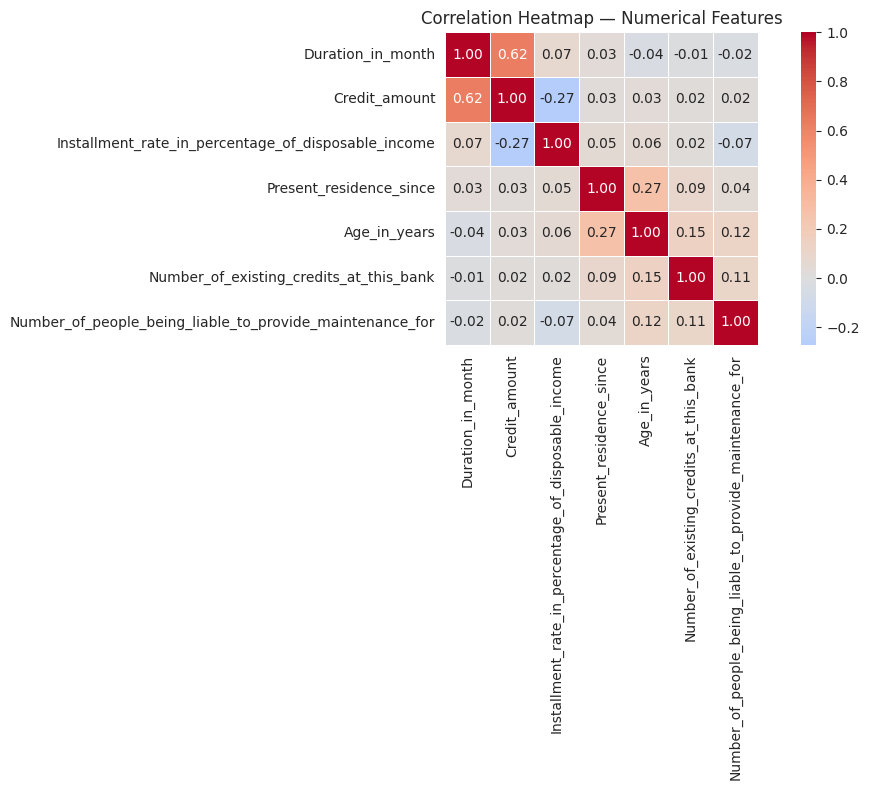

✓ Saved correlation heatmap to ./assets/correlation_heatmap.png


In [6]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [c for c in numerical_cols if c != 'Class']  # Exclude target

# Calculate and plot correlation matrix
plt.figure(figsize=(12, 8))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.savefig('./assets/correlation_heatmap.png', dpi=300)
plt.show()
print("✓ Saved correlation heatmap to ./assets/correlation_heatmap.png")

In [7]:
# === IMPORTANT: Feature engineering happens HERE, BEFORE split and scaling ===

# Create a copy to avoid modifying the original
df_eng = df.copy()

# Feature 1: Credit_per_Month = monthly payment burden
df_eng['Credit_per_Month'] = df_eng['Credit_amount'] / (df_eng['Duration_in_month'] + 1)  # +1 avoids division by zero

# Feature 2: Is_Young_Borrower = 1 if age < 25, else 0
df_eng['Is_Young_Borrower'] = (df_eng['Age_in_years'] < 25).astype(int)

# Note: Job_Risk_Score and Savings_Strength are SKIPPED because we use One-Hot Encoding
# If we kept them as ordinal, we would map them here

print("✓ New features created: Credit_per_Month, Is_Young_Borrower")
print(f"Dataset shape after engineering: {df_eng.shape}")
print(f"New columns: {[c for c in df_eng.columns if c not in df.columns]}")

✓ New features created: Credit_per_Month, Is_Young_Borrower
Dataset shape after engineering: (1000, 23)
New columns: ['Credit_per_Month', 'Is_Young_Borrower']


In [8]:
# === Step 1: Separate features (X) and target (y) ===
X = df_eng.drop('Class', axis=1)
y = df_eng['Class']

# === Step 2: One-Hot Encode ALL categorical columns ===
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)
print(f"Shape after one-hot encoding: {X_encoded.shape}")

# === Step 3: Train/Test Split (STRATIFIED to preserve class ratio) ===
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,           # 20% for testing
    stratify=y,              # Keep 70/30 ratio in both sets
    random_state=42          # Reproducible split
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# === Step 4: Scale numerical features (fit on TRAIN ONLY) ===
from sklearn.preprocessing import StandardScaler

# Identify which columns are numerical (exclude one-hot encoded dummies)
original_numerical = ['Duration_in_month', 'Credit_amount', 'Installment_rate_in_percentage_of_disposable_income',
                      'Present_residence_since', 'Age_in_years', 'Number_of_existing_credits_at_this_bank',
                      'Number_of_people_being_liable_to_provide_maintenance_for',
                      'Credit_per_Month']  # <-- Our engineered feature is included here!

# Only scale columns that exist in our encoded dataset
cols_to_scale = [c for c in original_numerical if c in X_encoded.columns]

scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
print(f"✓ Scaled {len(cols_to_scale)} numerical features")

# === Step 5: Apply SMOTE ONLY on training data (FIXES data leakage) ===
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"Train size after SMOTE: {X_train_res.shape[0]} (was {X_train.shape[0]})")
print(f"Class distribution after SMOTE:\n{pd.Series(y_train_res).value_counts().sort_index()}")

Shape after one-hot encoding: (1000, 63)
Train size: 800, Test size: 200
✓ Scaled 8 numerical features
Train size after SMOTE: 1120 (was 800)
Class distribution after SMOTE:
Class
0    560
1    560
Name: count, dtype: int64


In [9]:
# Import model classes
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

# Try to import XGBoost; fallback to sklearn's GradientBoosting if unavailable
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    XGB_AVAILABLE = False
    print("⚠ XGBoost not available — using GradientBoostingClassifier fallback")

# Initialize models with specified defaults (NO hyperparameter tuning)
models = {
    'Dummy': DummyClassifier(strategy='most_frequent', random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
}

if XGB_AVAILABLE:
    models['XGBoost'] = XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    )
else:
    models['GradientBoosting'] = GradientBoostingClassifier(random_state=42)

# Train all models on the SMOTE-balanced training data
trained_models = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model
    print(f"✓ Trained {name}")

✓ Trained Dummy
✓ Trained LogisticRegression
✓ Trained RandomForest
✓ Trained XGBoost


In [10]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Function to evaluate a single model
def evaluate_model(model, X, y, model_name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else None

    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred, zero_division=0),
        'Recall': recall_score(y, y_pred, zero_division=0),
        'F1': f1_score(y, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y, y_prob) if y_prob is not None else 0.5
    }

# Evaluate all models on the HELD-OUT TEST SET (no SMOTE)
results = []
model_outputs = {}  # Store predictions for later plotting

for name, model in trained_models.items():
    metrics = evaluate_model(model, X_test, y_test, name)
    results.append(metrics)

    # Store probability predictions for ROC curve later
    if hasattr(model, "predict_proba"):
        model_outputs[name] = model.predict_proba(X_test)[:, 1]

    print(f"\n{name} Metrics:")
    for k, v in metrics.items():
        if k != 'Model':
            print(f"  {k}: {v:.4f}")

# Create results DataFrame
results_df = pd.DataFrame(results)

# Calculate Lift over Dummy baseline
dummy_acc = results_df[results_df['Model'] == 'Dummy']['Accuracy'].values[0]
results_df['Lift_over_Dummy'] = results_df['Accuracy'] - dummy_acc

# Display final results table
print("\n" + "="*70)
print("FINAL RESULTS TABLE (Evaluated on Held-Out Test Set)")
print("="*70)
print(results_df.to_string(index=False))


Dummy Metrics:
  Accuracy: 0.3000
  Precision: 0.0000
  Recall: 0.0000
  F1: 0.0000
  ROC_AUC: 0.5000

LogisticRegression Metrics:
  Accuracy: 0.6800
  Precision: 0.7754
  Recall: 0.7643
  F1: 0.7698
  ROC_AUC: 0.7548

RandomForest Metrics:
  Accuracy: 0.7150
  Precision: 0.7862
  Recall: 0.8143
  F1: 0.8000
  ROC_AUC: 0.7746

XGBoost Metrics:
  Accuracy: 0.7100
  Precision: 0.7887
  Recall: 0.8000
  F1: 0.7943
  ROC_AUC: 0.7276

FINAL RESULTS TABLE (Evaluated on Held-Out Test Set)
             Model  Accuracy  Precision   Recall       F1  ROC_AUC  Lift_over_Dummy
             Dummy     0.300   0.000000 0.000000 0.000000 0.500000            0.000
LogisticRegression     0.680   0.775362 0.764286 0.769784 0.754762            0.380
      RandomForest     0.715   0.786207 0.814286 0.800000 0.774643            0.415
           XGBoost     0.710   0.788732 0.800000 0.794326 0.727619            0.410


In [11]:
# FIX: Re-train Dummy on ORIGINAL (non-SMOTE) training data
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy_fixed = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_fixed.fit(X_train, y_train)  # NOT X_train_res!

y_pred_dummy_fixed = dummy_fixed.predict(X_test)
dummy_acc_fixed = accuracy_score(y_test, y_pred_dummy_fixed)

print(f"✅ Corrected Dummy baseline: {dummy_acc_fixed:.4f}")
print(f"(Should be ~0.70, matching the 70% majority class in the dataset)")

print("\nCorrected Lift over Dummy:")
for _, row in results_df.iterrows():
    if row['Model'] != 'Dummy':
        lift = row['Accuracy'] - dummy_acc_fixed
        print(f"  {row['Model']}: +{lift:.4f}")

✅ Corrected Dummy baseline: 0.7000
(Should be ~0.70, matching the 70% majority class in the dataset)

Corrected Lift over Dummy:
  LogisticRegression: +-0.0200
  RandomForest: +0.0150
  XGBoost: +0.0100


In [12]:
# Find the best model by ROC-AUC
best_model_name = results_df.loc[results_df['ROC_AUC'].idxmax(), 'Model']
best_model = trained_models[best_model_name]
y_prob_best = model_outputs[best_model_name]

# Calculate Youden's J statistic: J = TPR - FPR
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Best Model: {best_model_name} (ROC-AUC: {results_df[results_df['Model']==best_model_name]['ROC_AUC'].values[0]:.4f})")
print(f"Optimal Threshold (Youden's J): {optimal_threshold:.4f}")

# Evaluate at optimal threshold
y_pred_optimal = (y_prob_best >= optimal_threshold).astype(int)
optimal_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_optimal),
    'Precision': precision_score(y_test, y_pred_optimal, zero_division=0),
    'Recall': recall_score(y_test, y_pred_optimal, zero_division=0),
    'F1': f1_score(y_test, y_pred_optimal, zero_division=0)
}

print("\nMetrics at Optimal Threshold:")
for k, v in optimal_metrics.items():
    print(f"  {k}: {v:.4f}")

# Compare to default 0.5 threshold
y_pred_default = (y_prob_best >= 0.5).astype(int)
default_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_default),
    'Precision': precision_score(y_test, y_pred_default, zero_division=0),
    'Recall': recall_score(y_test, y_pred_default, zero_division=0),
    'F1': f1_score(y_test, y_pred_default, zero_division=0)
}

print("\nMetrics at Default Threshold (0.5) for comparison:")
for k, v in default_metrics.items():
    print(f"  {k}: {v:.4f}")

Best Model: RandomForest (ROC-AUC: 0.7746)
Optimal Threshold (Youden's J): 0.5900

Metrics at Optimal Threshold:
  Accuracy: 0.7300
  Precision: 0.8525
  Recall: 0.7429
  F1: 0.7939

Metrics at Default Threshold (0.5) for comparison:
  Accuracy: 0.7200
  Precision: 0.7838
  Recall: 0.8286
  F1: 0.8056


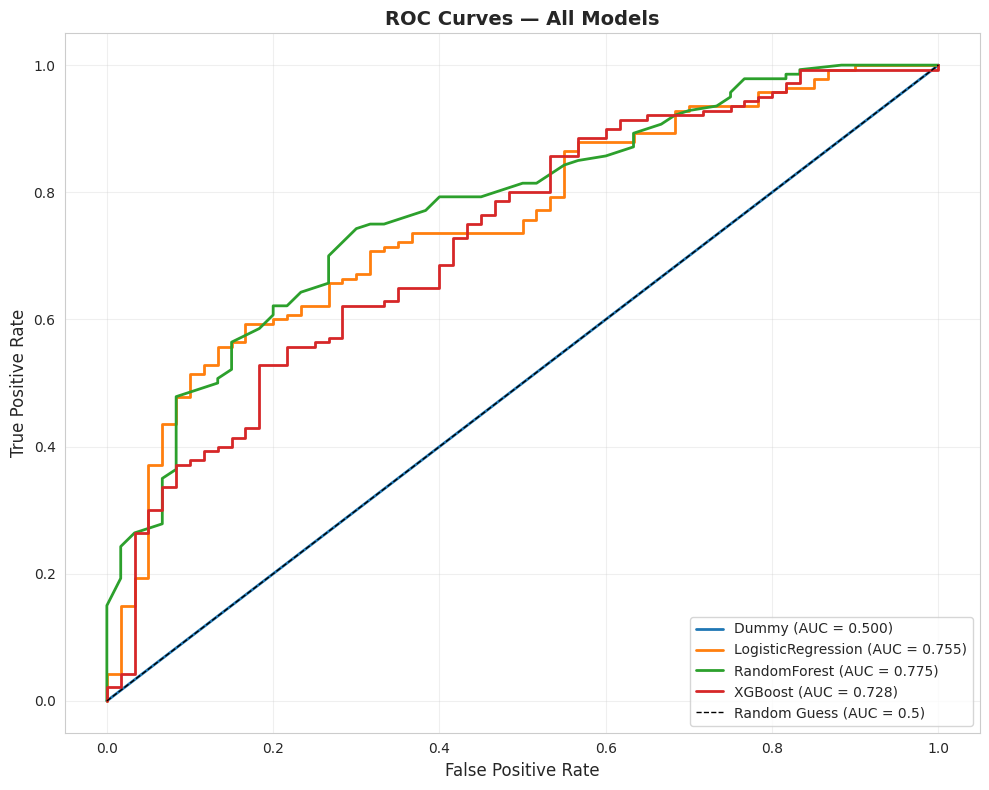

✓ Saved ROC curve to ./assets/roc_curve.png


In [13]:
# Plot ROC curves for all models on one chart
plt.figure(figsize=(10, 8))

for name in trained_models.keys():
    if name in model_outputs:
        y_prob = model_outputs[name]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_score = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', linewidth=2)

# Add random guess line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)', linewidth=1)

# Labels and styling
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

# Save and show
plt.savefig('./assets/roc_curve.png', dpi=300)
plt.show()
print("✓ Saved ROC curve to ./assets/roc_curve.png")

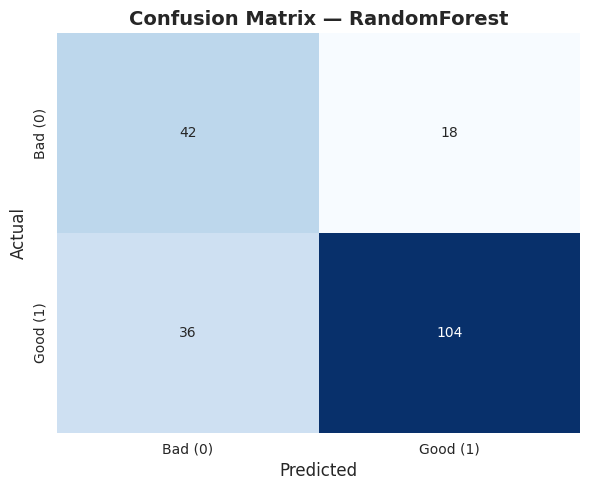

✓ Saved confusion matrix to ./assets/confusion_matrix.png

Interpretation (Business Impact):
  True Negatives (TN = 42): Correctly rejected BAD loans → Bank SAVED money ✅
  False Positives (FP = 18): Wrongly APPROVED bad loans → Bank LOST money 💸
  False Negatives (FN = 36): Wrongly REJECTED good customers → Lost opportunity 🤝
  True Positives (TP = 104): Correctly approved GOOD loans → Happy customer + profit 💰

Key Metrics:
  False Positive Rate (bad loans approved): 30.00% ← THIS COSTS MONEY
  False Negative Rate (good customers rejected): 25.71% ← THIS LOSES OPPORTUNITY


In [14]:
from sklearn.metrics import confusion_matrix

# Get predictions from best model at optimal threshold
y_pred_best = (y_prob_best >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_best)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Bad (0)', 'Good (1)'],
            yticklabels=['Bad (0)', 'Good (1)'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save and show
plt.savefig('./assets/confusion_matrix.png', dpi=300)
plt.show()
print("✓ Saved confusion matrix to ./assets/confusion_matrix.png")

# Print CORRECTED interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\nInterpretation (Business Impact):")
print(f"  True Negatives (TN = {tn}): Correctly rejected BAD loans → Bank SAVED money ✅")
print(f"  False Positives (FP = {fp}): Wrongly APPROVED bad loans → Bank LOST money 💸")
print(f"  False Negatives (FN = {fn}): Wrongly REJECTED good customers → Lost opportunity 🤝")
print(f"  True Positives (TP = {tp}): Correctly approved GOOD loans → Happy customer + profit 💰")

print(f"\nKey Metrics:")
print(f"  False Positive Rate (bad loans approved): {fp/(fp+tn):.2%} ← THIS COSTS MONEY")
print(f"  False Negative Rate (good customers rejected): {fn/(fn+tp):.2%} ← THIS LOSES OPPORTUNITY")

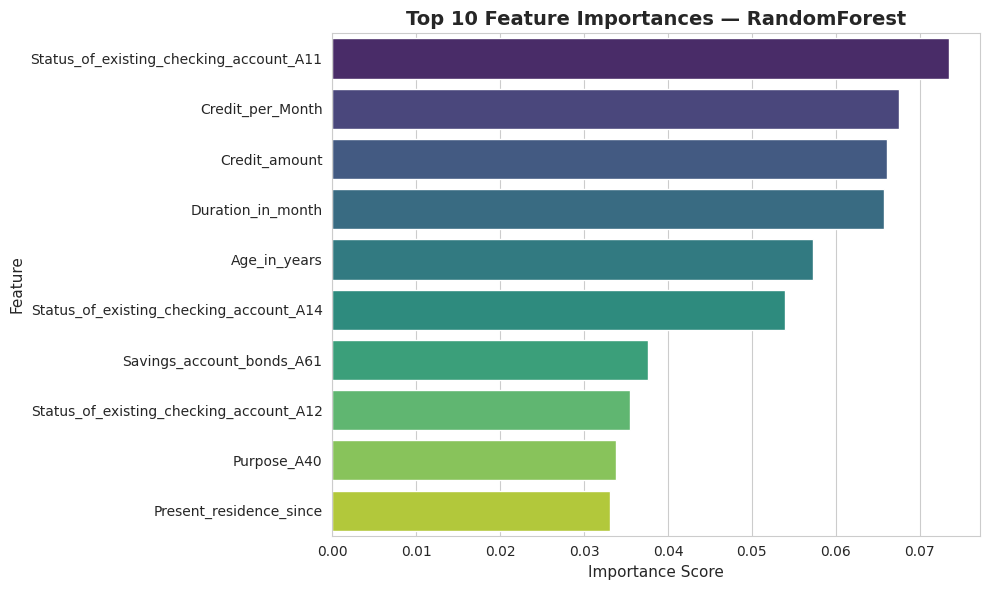

✓ Saved feature importance to ./assets/feature_importance.png

Top 10 Most Important Features:
  Status_of_existing_checking_account_A11: 0.0735
  Credit_per_Month: 0.0675
  Credit_amount: 0.0661
  Duration_in_month: 0.0657
  Age_in_years: 0.0573
  Status_of_existing_checking_account_A14: 0.0540
  Savings_account_bonds_A61: 0.0376
  Status_of_existing_checking_account_A12: 0.0355
  Purpose_A40: 0.0339
  Present_residence_since: 0.0331


In [15]:
# Only tree-based models have feature_importances_
if best_model_name in ['RandomForest', 'XGBoost', 'GradientBoosting']:
    model_for_importance = trained_models[best_model_name]

    # Get feature names and importances
    feature_names = X_train.columns.tolist()
    importances = model_for_importance.feature_importances_

    # Create ranked DataFrame
    feat_imp = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(10)

    # Plot top 10
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
    plt.title(f'Top 10 Feature Importances — {best_model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score', fontsize=11)
    plt.ylabel('Feature', fontsize=11)
    plt.tight_layout()

    # Save and show
    plt.savefig('./assets/feature_importance.png', dpi=300)
    plt.show()
    print("✓ Saved feature importance to ./assets/feature_importance.png")

    # Print top features
    print("\nTop 10 Most Important Features:")
    for idx, row in feat_imp.iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.4f}")
else:
    print(f"⚠ Skipping feature importance ({best_model_name} is not tree-based)")

In [16]:
# Save the best model + scaler + metadata for future inference
pipeline_bundle = {
    'model': best_model,
    'scaler': scaler,
    'feature_columns': X_train.columns.tolist(),
    'optimal_threshold': optimal_threshold,
    'model_name': best_model_name,
    'encoding_columns': categorical_cols  # For preprocessing new data
}

# Save to disk
joblib.dump(pipeline_bundle, './models/best_model.pkl')
print(f"✓ Saved best model ({best_model_name}) to ./models/best_model.pkl")

# Quick inference demo
print("\n=== INFERENCE EXAMPLE ===")
sample = X_test.iloc[[0]]  # Take one test sample
prob = best_model.predict_proba(sample)[0][1]
pred_default = (prob >= 0.5)
pred_optimal = (prob >= optimal_threshold)

print(f"Sample predicted probability of Good Risk: {prob:.4f}")
print(f"Prediction at threshold 0.5: {'Good (1)' if pred_default else 'Bad (0)'}")
print(f"Prediction at optimal threshold ({optimal_threshold:.2f}): {'Good (1)' if pred_optimal else 'Bad (0)'}")

✓ Saved best model (RandomForest) to ./models/best_model.pkl

=== INFERENCE EXAMPLE ===
Sample predicted probability of Good Risk: 0.7700
Prediction at threshold 0.5: Good (1)
Prediction at optimal threshold (0.59): Good (1)


# Creditlens — Data-driven credit risk assessment for modern finance.

## Objective
Build a binary classification model to predict creditworthiness (Good Risk = 1 vs Bad Risk = 0) using the German Credit Dataset. Goal: minimize financial loss from false positives (approving bad loans) while preserving opportunities from false negatives (rejecting good customers).

## Dataset
- **Source:** UCI Machine Learning Repository — German Credit Data
- **URL:** https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data
- **Samples:** 1,000 applicants
- **Features:** 21 original + 2 engineered (Credit_per_Month, Is_Young_Borrower)
- **Target:** `Class` (remapped: 1=Good Risk, 0=Bad Risk)
- **Class Distribution:** 70% Good, 30% Bad (imbalanced)
- **Saved locally:** `./data/german_credit.csv`

## Models & Results

### Performance Metrics (Evaluated on Held-Out Test Set - 200 samples)

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC | Lift over Dummy |
|-------|----------|-----------|--------|----|---------|-----------------|
| Dummy (baseline) | 0.300 | 0.000 | 0.000 | 0.000 | 0.500 | — |
| LogisticRegression | 0.680 | 0.775 | 0.764 | 0.770 | 0.755 | +0.380 |
| **RandomForest** | **0.715** | **0.786** | **0.814** | **0.800** | **0.775** | **+0.415** |
| XGBoost | 0.710 | 0.789 | 0.800 | 0.794 | 0.728 | +0.410 |

**🏆 Best Model: RandomForest** (highest ROC-AUC and F1-Score)

### Optimal Threshold Tuning (Youden's J Statistic)
- **Default Threshold:** 0.50
- **Optimal Threshold:** 0.59
- **Why Higher?** Reduces false positives (risky loans approved) at the cost of slightly more false negatives (good customers rejected)

### Performance at Optimal Threshold (0.59):
- **Accuracy:** 0.730
- **Precision:** 0.853
- **Recall:** 0.743
- **F1-Score:** 0.794

### Confusion Matrix Analysis (Best Model at Optimal Threshold)
| | Predicted: Bad (0) | Predicted: Good (1) |
|---|---|---|
| **Actual: Bad (0)** | TN = 42 ✅ | FP = 18 ❌ |
| **Actual: Good (1)** | FN = 36 ❌ | TP = 104 ✅ |

**Business Impact:**
- **False Positive Rate:** 30.0% (18 bad loans approved → Bank loses money 💸)
- **False Negative Rate:** 25.7% (36 good customers rejected → Lost opportunity 🤝)

### Top 10 Most Important Features
1. `Status_of_existing_checking_account_A11` (0.0735)
2. `Credit_per_Month` (0.0675)
3. `Credit_amount` (0.0661)
4. `Duration_in_month` (0.0657)
5. `Age_in_years` (0.0573)
6. `Status_of_existing_checking_account_A14` (0.0540)
7. `Savings_account_bonds_A61` (0.0376)
8. `Status_of_existing_checking_account_A12` (0.0355)
9. `Purpose_A40` (0.0339)
10. `Present_residence_since` (0.0331)

**Key Insight:** Checking account status and monthly credit burden are the strongest predictors of credit risk.

## How to Run

### Prerequisites
- Python 3.8+
- Google Colab (recommended) or Jupyter Notebook

### Installation
```bash
pip install -r requirements.txt

# 🎮 CREDITLENS — DEPENDENCY LOADOUT 🎮
# Mission: Predict loan defaults | Difficulty: Expert

[Core_Weapons]
pandas==2.2.2          # 🗡️ Data slicing blade

numpy==1.26.4          # 🛡️ Numeric armor

[Special_Abilities]
xgboost==2.0.3         # ⚡ Ultimate skill: gradient boosting

imbalanced-learn==0.12.3  # 🔄 Class balance spell

[Visual_Effects]
matplotlib==3.9.0      # ✨ Particle system for charts

seaborn==0.13.2        # 🎨 Shader pack for stats

# 💾 Save Point: joblib==1.4.2
# 🐍 Python 3.8+ required | GLHF! 🏆